##### Checking Out the dataset KKBOX Music. Checking the dataset for patterns. When does a user listen to a song on repeat? Can we create a model and predict the features which increase the possibility of the music been heard on repeat? 
##### EDA FOR MEMBERS CSV

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

In [36]:
df1 = pd.read_csv("members.csv")

In [38]:
df1.head(2)

,msno,city,bd,gender,registered_via,registration_init_time,expiration_date
0,XQxgAYj3klVKjR3oxPPXYYFp4soD4TuBghkhMTD4oTw=,1,0,NaN,7,20110820,20170920
1,UizsfmJb9mV54qE9hCYyU07Va97c0lCRLEQX3ae+ztM=,1,0,NaN,7,20150628,20170622


In [40]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34403 entries, 0 to 34402
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   msno                    34403 non-null  object
 1   city                    34403 non-null  int64 
 2   bd                      34403 non-null  int64 
 3   gender                  14501 non-null  object
 4   registered_via          34403 non-null  int64 
 5   registration_init_time  34403 non-null  int64 
 6   expiration_date         34403 non-null  int64 
dtypes: int64(5), object(2)
memory usage: 1.8+ MB


In [42]:
df1.shape

(34403, 7)

In [44]:
df1.isnull().sum()

msno                          0
city                          0
bd                            0
gender                    19902
registered_via                0
registration_init_time        0
expiration_date               0
dtype: int64

In [46]:
df1['gender'].fillna('unknown', inplace=True)

In [48]:
df1.duplicated().sum()

0

In [52]:
df1['gender'].value_counts()

gender
unknown    19902
male        7405
female      7096
Name: count, dtype: int64

In [54]:
# Convert to datetime format
df1['registration_init_time'] = pd.to_datetime(df1['registration_init_time'], format='%Y%m%d')
df1['expiration_date'] = pd.to_datetime(df1['expiration_date'], format='%Y%m%d')

# Calculate membership duration
df1['membership_days'] = (df1['expiration_date'] - df1['registration_init_time']).dt.days

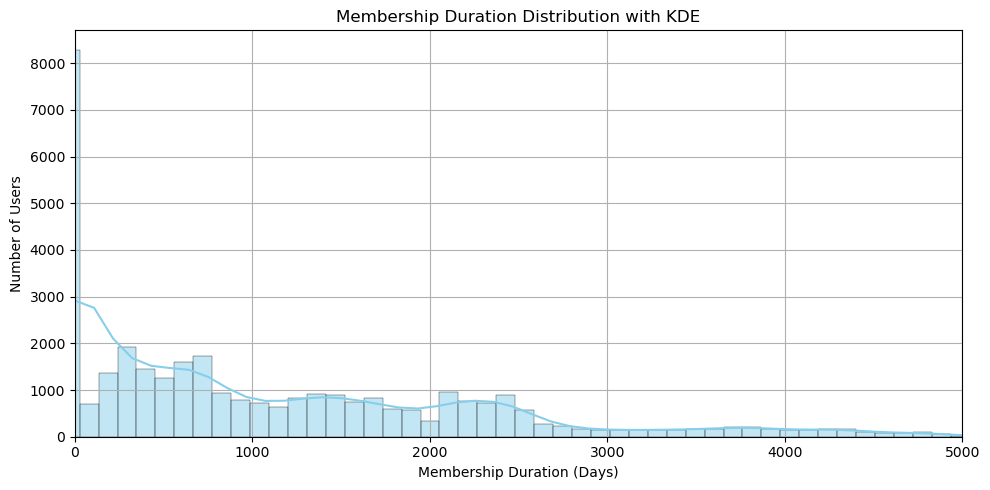

In [78]:
plt.figure(figsize=(10, 5))
sns.histplot(df1['membership_days'], bins=200, kde=True, color='skyblue', edgecolor='black')
plt.title('Membership Duration Distribution with KDE')
plt.xlabel('Membership Duration (Days)')
plt.ylabel('Number of Users')
plt.xlim(0, 5000)
plt.grid(True)
plt.tight_layout()
plt.show();

In [64]:
df1['membership_days'].describe()

count    34403.000000
mean      1091.632474
std       1151.438441
min     -16191.000000
25%         72.000000
50%        701.000000
75%       1769.000000
max       5149.000000
Name: membership_days, dtype: float64

In [68]:
df1.head(2)

,msno,city,bd,gender,registered_via,registration_init_time,expiration_date,membership_days
0,XQxgAYj3klVKjR3oxPPXYYFp4soD4TuBghkhMTD4oTw=,1,0,unknown,7,2011-08-20,2017-09-20,2223
1,UizsfmJb9mV54qE9hCYyU07Va97c0lCRLEQX3ae+ztM=,1,0,unknown,7,2015-06-28,2017-06-22,725


##### bd means birthdate or age which has outlier values. 

In [83]:
df1['age_group'] = pd.cut(df1['bd'], bins=[10, 20, 30, 40, 50, 60, 70, 100],
                          labels=['10s', '20s', '30s', '40s', '50s', '60s', '70+'])

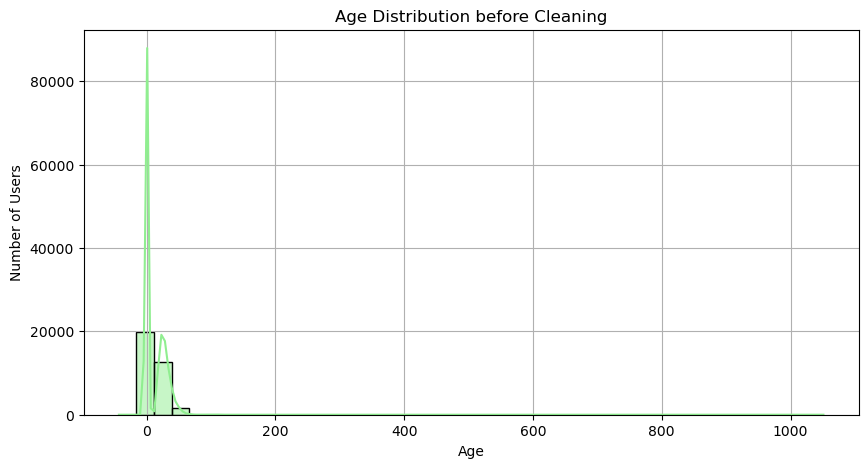

In [89]:
plt.figure(figsize=(10, 5))
sns.histplot(df1['bd'], bins=40, kde=True, color='lightgreen')
plt.title('Age Distribution before Cleaning')
plt.xlabel('Age')
plt.ylabel('Number of Users')
plt.grid(True)
plt.show()

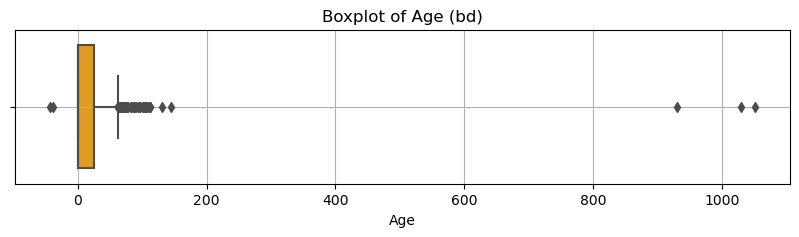

In [91]:
plt.figure(figsize=(10, 2))
sns.boxplot(x=df1['bd'], color='orange')
plt.title('Boxplot of Age (bd)')
plt.xlabel('Age')
plt.grid(True)
plt.show()

IQR: 25.0
Lower Bound: -37.5
Upper Bound: 62.5


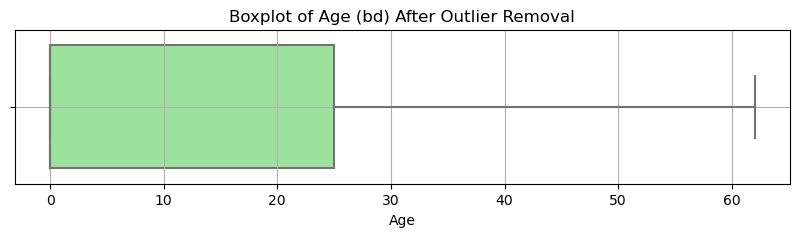

In [93]:
# 🧮 Step 2: Calculate IQR and bounds
Q1 = df1['bd'].quantile(0.25)
Q3 = df1['bd'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f'IQR: {IQR}')
print(f'Lower Bound: {lower_bound}')
print(f'Upper Bound: {upper_bound}')

# ✂️ Step 3: Remove outliers from bd
df1 = df1[(df1['bd'] >= lower_bound) & (df1['bd'] <= upper_bound)]

# ✅ Step 4: Confirm with updated boxplot
plt.figure(figsize=(10, 2))
sns.boxplot(x=df1['bd'], color='lightgreen')
plt.title('Boxplot of Age (bd) After Outlier Removal')
plt.xlabel('Age')
plt.grid(True)
plt.show()

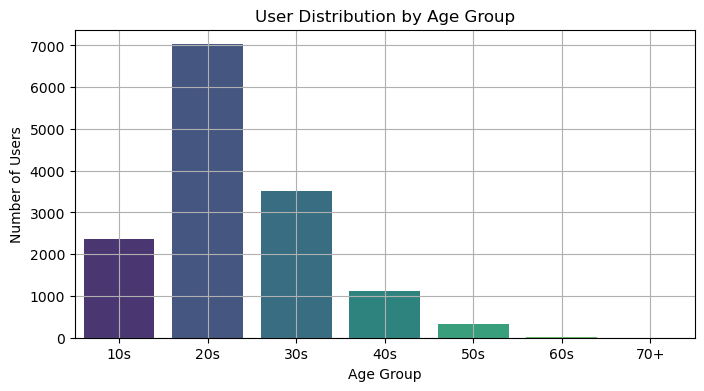

In [97]:
plt.figure(figsize=(8, 4))

# Keep the original order of age groups as defined in pd.cut
sns.countplot(x='age_group', data=df1, palette='viridis', order=df1['age_group'].cat.categories)

plt.title('User Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Users')
plt.grid(True)
plt.show()

In [99]:
df1.describe()

,city,bd,registered_via,registration_init_time,expiration_date,membership_days
count,34311.000000,34311.000000,34311.000000,34311,34311,34311.000000
mean,5.362070,12.027484,5.953368,2014-06-09 02:07:50.263181056,2017-06-03 12:08:14.815074048,1090.416951
min,1.000000,0.000000,3.000000,2004-03-26 00:00:00,1970-01-01 00:00:00,-16191.000000
25%,1.000000,0.000000,4.000000,2012-10-30 00:00:00,2017-02-01 00:00:00,70.000000
50%,1.000000,0.000000,7.000000,2015-09-05 00:00:00,2017-09-09 00:00:00,700.000000
75%,10.000000,25.000000,9.000000,2016-11-02 00:00:00,2017-09-30 00:00:00,1766.000000
max,22.000000,62.000000,16.000000,2017-02-28 00:00:00,2020-10-17 00:00:00,5149.000000
std,6.241252,15.241990,2.286385,NaN,NaN,1150.479135


In [101]:
df1 = df1[df1['expiration_date'] != pd.to_datetime('1970-01-01')]
df1['expiration_date'] = df1['expiration_date'].replace(pd.to_datetime('1970-01-01'), pd.NaT)

In [105]:
df1.describe(include='all')

,msno,city,bd,gender,registered_via,registration_init_time,expiration_date,membership_days,age_group
count,34310,34310.000000,34310.000000,34310,34310.000000,34310,34310,34310.000000,14373
unique,34310,NaN,NaN,3,NaN,NaN,NaN,NaN,6
top,XQxgAYj3klVKjR3oxPPXYYFp4soD4TuBghkhMTD4oTw=,NaN,NaN,unknown,NaN,NaN,NaN,NaN,20s
freq,1,NaN,NaN,19897,NaN,NaN,NaN,NaN,7024
mean,NaN,5.362198,12.027834,NaN,5.953279,2014-06-09 02:09:28.697172736,2017-06-04 00:15:11.594287360,1090.920635,NaN
min,NaN,1.000000,0.000000,NaN,3.000000,2004-03-26 00:00:00,2004-10-15 00:00:00,0.000000,NaN
25%,NaN,1.000000,0.000000,NaN,4.000000,2012-10-30 00:00:00,2017-02-01 00:00:00,70.000000,NaN
50%,NaN,1.000000,0.000000,NaN,7.000000,2015-09-05 00:00:00,2017-09-09 00:00:00,700.000000,NaN
75%,NaN,10.000000,25.000000,NaN,9.000000,2016-11-02 00:00:00,2017-09-30 00:00:00,1766.000000,NaN
max,NaN,22.000000,62.000000,NaN,16.000000,2017-02-28 00:00:00,2020-10-17 00:00:00,5149.000000,NaN


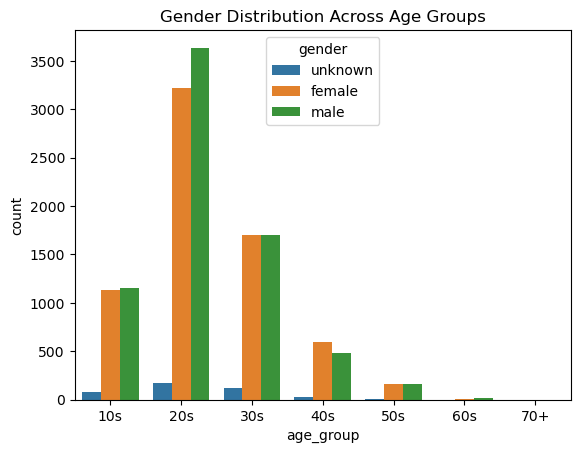

In [109]:
sns.countplot(x='age_group', hue='gender', data=df1)
plt.title('Gender Distribution Across Age Groups')
plt.show()

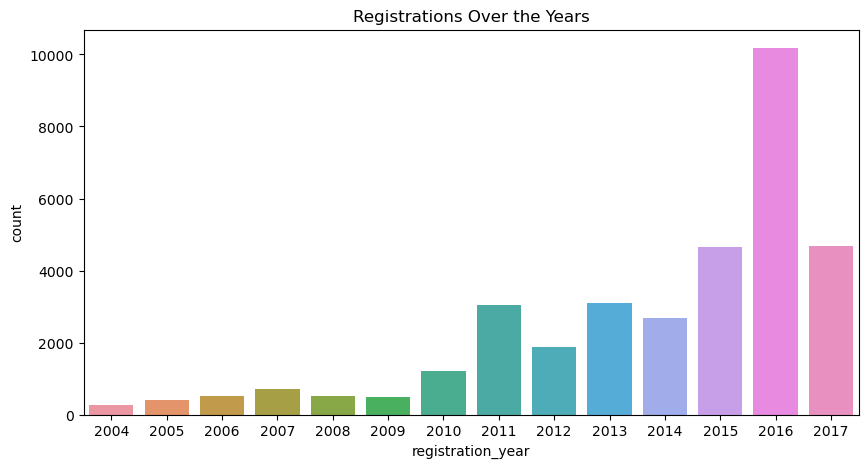

In [125]:
plt.figure(figsize=(10, 5))
df1['registration_year'] = df1['registration_init_time'].dt.year
sns.countplot(x='registration_year', data=df1)
plt.title('Registrations Over the Years')
plt.show()

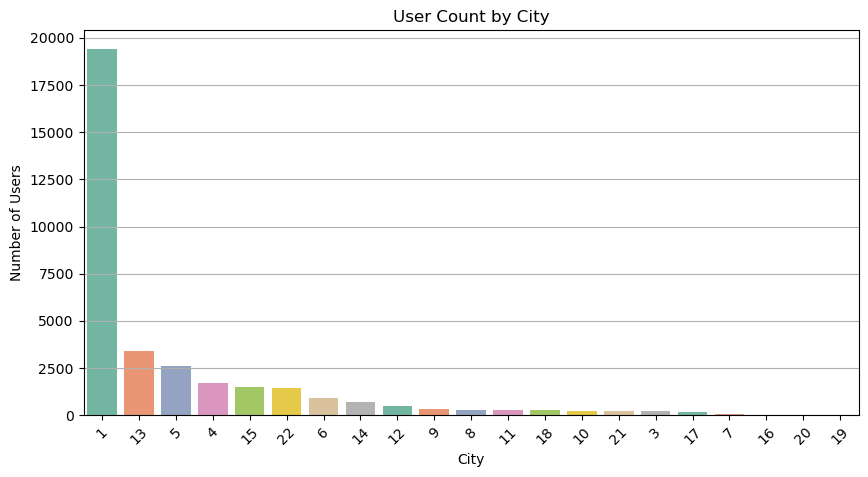

In [113]:
plt.figure(figsize=(10, 5))
sns.countplot(x='city', data=df1, order=df1['city'].value_counts().index, palette='Set2')
plt.title('User Count by City')
plt.xlabel('City')
plt.ylabel('Number of Users')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

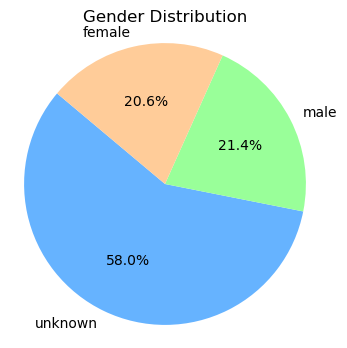

In [123]:
gender_counts = df1['gender'].value_counts()
plt.figure(figsize=(4, 4))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', colors=['#66b3ff','#99ff99','#ffcc99'], startangle=140)
plt.title('Gender Distribution')
plt.axis('equal')
plt.show()

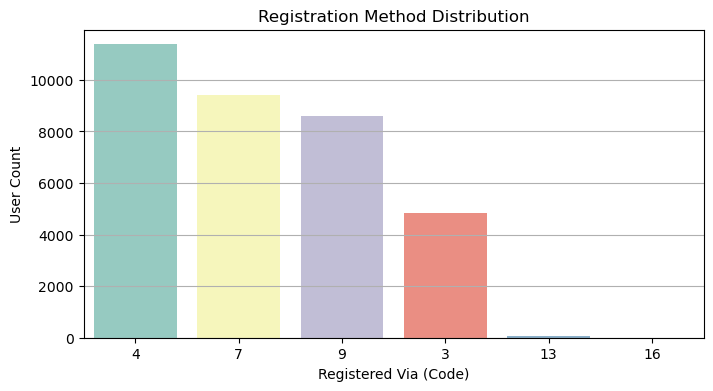

In [121]:
plt.figure(figsize=(8, 4))
sns.countplot(x='registered_via', data=df1, palette='Set3', order=df1['registered_via'].value_counts().index)
plt.title('Registration Method Distribution')
plt.xlabel('Registered Via (Code)')
plt.ylabel('User Count')
plt.grid(axis='y')
plt.show()


In [130]:
# Drop bd < 10 again (seems like 0s remained)
df1 = df1[df1['bd'] >= 10]

# Drop membership_days <= 0
df1 = df1[df1['membership_days'] > 0]

# Reset index
df1 = df1.reset_index(drop=True)

In [132]:
df1.describe(include='all')

,msno,city,bd,gender,registered_via,registration_init_time,expiration_date,membership_days,age_group,registration_year
count,14367,14367.000000,14367.000000,14367,14367.000000,14367,14367,14367.000000,14366,14367.000000
unique,14367,NaN,NaN,3,NaN,NaN,NaN,NaN,6,NaN
top,zgPOEyUn5a/Fvuzb3m69ajzxjkbblVtObglW89FzLdo=,NaN,NaN,male,NaN,NaN,NaN,NaN,20s,NaN
freq,1,NaN,NaN,7148,NaN,NaN,NaN,NaN,7024,NaN
mean,NaN,10.416440,28.709403,NaN,6.560729,2012-09-26 12:20:29.818333696,2017-07-28 00:27:09.734809088,1765.504629,NaN,2012.224334
min,NaN,1.000000,10.000000,NaN,3.000000,2004-03-26 00:00:00,2005-06-10 00:00:00,1.000000,NaN,2004.000000
25%,NaN,5.000000,22.000000,NaN,3.000000,2010-12-20 00:00:00,2017-07-11 00:00:00,723.500000,NaN,2010.000000
50%,NaN,12.000000,27.000000,NaN,7.000000,2013-03-01 00:00:00,2017-09-21 00:00:00,1634.000000,NaN,2013.000000
75%,NaN,14.000000,34.000000,NaN,9.000000,2015-08-05 00:00:00,2017-10-06 00:00:00,2479.000000,NaN,2015.000000
max,NaN,22.000000,62.000000,NaN,13.000000,2017-02-28 00:00:00,2020-10-17 00:00:00,5149.000000,NaN,2017.000000


In [136]:
df1['age_group'] = df1['age_group'].fillna('20s')  # or infer from `bd`
df1['reg_month'] = df1['registration_init_time'].dt.month
df1['reg_weekday'] = df1['registration_init_time'].dt.weekday

In [138]:
print("Registrations by Month:")
print(df1['reg_month'].value_counts().sort_index())

print("\nRegistrations by Weekday (0 = Monday):")
print(df1['reg_weekday'].value_counts().sort_index())

Registrations by Month:
reg_month
1     1541
2     1295
3     1087
4      829
5      851
6     1183
7      923
8     1203
9     1178
10    1319
11    1423
12    1535
Name: count, dtype: int64

Registrations by Weekday (0 = Monday):
reg_weekday
0    1870
1    1883
2    1911
3    1898
4    2094
5    2406
6    2305
Name: count, dtype: int64


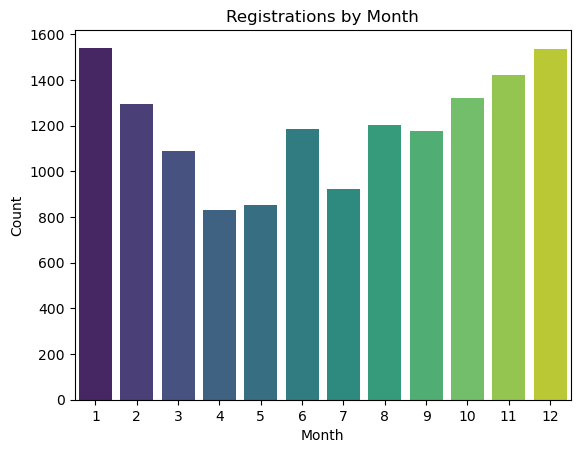

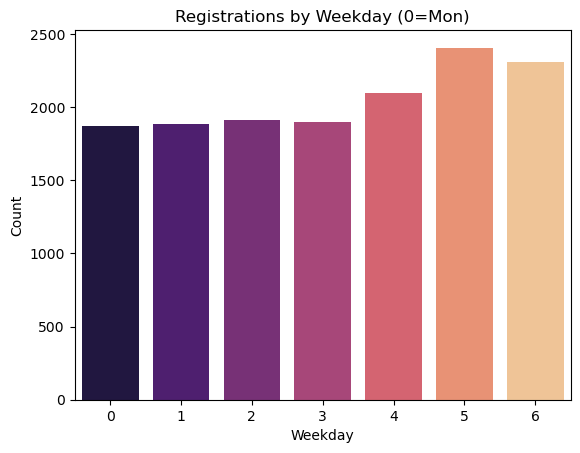

In [142]:
# Month Plot
sns.countplot(data=df1, x='reg_month', palette='viridis')
plt.title('Registrations by Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.show()
# Weekday Plot
sns.countplot(data=df1, x='reg_weekday', palette='magma')
plt.title('Registrations by Weekday (0=Mon)')
plt.xlabel('Weekday')
plt.ylabel('Count')
plt.show()

In [144]:
df1.to_csv('members_eda.csv', index=False)